# Datasets, `SummarizedExperiment`, and `GRanges`

## Learning Outcomes

By the end of this notebook, you will be able to:

- Understand the structure of `SummarizedExperiment` and `GRanges` objects in `R`.
- Access and manipulate metadata and assays within `SummarizedExperiment`.
- Visualize and subset genomic intervals using `GRanges`.
- Recognize how even RNA expression data can be stored as genomic ranges.

::: {.callout-note}
**Note:** Genomic data types like RNA-seq are often stored as `SummarizedExperiment` or `GRanges`, which are efficient for multi-omics integration.
:::

## Dataset for the course

In this course, we are working with **multi-omics datasets** derived from the developing **mouse neural tube** at two developmental stages: **E11.5** and **E15.5**. These stages represent key transitions in central nervous system development. These datasets are downloaded and processed from the ENCODE project: [Mouse Development Matrix](https://www.encodeproject.org/mouse-development-matrix/?type=Experiment&status=released&related_series.@type=OrganismDevelopmentSeries&replicates.library.biosample.organism.scientific_name=Mus+musculus#neural_tube). For the sake of time and efficient computational usage, datasets are analyzed for only chromosomes 1 and 2.

The following chromatin and transcriptional profiling datasets are included, each with **two biological replicates per time point**:

| Assay        | Description                                                 | E11.5 | E15.5 |
| ------------ | ----------------------------------------------------------- | ----- | ----- |
| **ATAC-seq** | Chromatin accessibility profiling                           | 2     | 2     |
| **H3K4me3**  | Histone mark at active promoters                            | 2     | 2     |
| **H3K4me1**  | Histone mark at enhancers and poised regulatory elements    | 2     | 2     |
| **H3K27me3** | Repressive histone modification (Polycomb repression)       | 2     | 2     |
| **H3K27ac**  | Active enhancer and promoter histone mark                   | 2     | 2     |
| **RNA-seq**  | Gene expression quantification via transcriptome sequencing | 2     | 2     |

All datasets are preprocessed and stored in **`SummarizedExperiment` (SE)** objects:

* **Assays** contain count matrices (e.g., raw counts, logCPM).
* **RowRanges** describe genomic coordinates (`GRanges`) for each feature (gene, peak, region).
* **ColData** holds metadata for each sample (e.g., stage, replicate).

The use of `SE` objects enables consistent handling of multi-omics data, facilitates downstream integration, and supports interoperability with Bioconductor tools.

* `SummarizedExperiment` enables structured storage of high-dimensional omics data and metadata.
* `GRanges` makes it easy to manipulate and visualize genomic intervals across datasets.
* Most analyses — from clustering to visualization — can be performed directly on these containers.

## Download and Extract Data

_Note: run the following only once for the entire course._

In [1]:
# Download and unpack data only if not already present
if (!dir.exists("data")) {
  dir.create("data")
  
  # Increase timeout for large file transfer
  options(timeout = 1000)
  
  message("Downloading course datasets...")
  download.file(
    url = "https://biology-informed-multiomics.s3.eu-central-1.amazonaws.com/biology-informed-multiomics.tar",
    destfile = "data/data.tar",
    mode = "wb"  # Binary mode required for Windows
  )
  
  message("Extracting archive...")
  untar(tarfile = "data/data.tar", exdir = "data")
  file.remove("data/data.tar")
  message("Done! Data ready in ./data")
} else {
  message("Data directory already exists. Skipping download.")
}

Data directory already exists. Skipping download.



## Load Libraries

In [2]:
# Expand the maximum printed width to 150 characters (or any number you prefer)
options(width = 140)

In [3]:
# suppress warnings and messages
suppressPackageStartupMessages(suppressWarnings({
  library(ComplexHeatmap)
  library(SummarizedExperiment)
}))

library(ComplexHeatmap)
library(SummarizedExperiment)
library(ggplot2)
library(tidyr)
library(GenomicRanges)


Attachement du package : 'tidyr'


L'objet suivant est masqué depuis 'package:S4Vectors':

    expand




## Load SummarizedExperiment Objects

In [4]:
rna <- readRDS("data/rna_se.rds")
atac <- readRDS("data/atac_se.rds")
h3k4me3 <- readRDS("data/h3k4me3_se.rds")
h3k4me1 <- readRDS("data/h3k4me1_se.rds")
h3k27me3 <- readRDS("data/h3k27me3_se.rds")
h3k27ac <- readRDS("data/h3k27ac_se.rds")

The function `readRDS()` is not part of the SummarizedExperiment package. It is a standard R function used to read a single R object that was previously saved using saveRDS(). Because SummarizedExperiment objects are just specialized R objects, they can be saved and loaded using these standard base R functions.

## Working with `SummarizedExperiment` (SE)

### Inspect the RNA SE Object

In [5]:
rna

class: RangedSummarizedExperiment 
dim: 2216 4 
metadata(0):
assays(2): counts logCPM
rownames(2216): ENSMUSG00000000194 ENSMUSG00000000247 ... ENSMUSG00000103948 ENSMUSG00000104257
rowData names(18): Row.names gene_id ... PValue qvalue
colnames(4): RNA_11half_1.tsv.gz RNA_11half_2.tsv.gz RNA_15half_1.tsv.gz RNA_15half_2.tsv.gz
colData names(2): sample group

When we use `readRDS("data/rna_se.rds")`, it doesn't just read raw text or numbers (like read.csv would), but it completely restores the R object from the file exactly as it was when it was saved. Since the original object saved into that file was a `RangedSummarizedExperiment` class, that is exactly what gets loaded back into the `rna` variable.

### Access `rowRanges`, `colData`, and `assays`

The `rowRanges()` accessor is used to view the range information for a RangedSummarizedExperiment. (Note if this were the parent SummarizedExperiment class we'd use `rowData()`). The data are stored in a GRangesList (*Genomic Ranges*) object, where each list element corresponds to one gene transcript (*feature*) and the ranges in each GRanges correspond to the exons in the transcript.

In [6]:
rowRanges(rna)

GRanges object with 2216 ranges and 18 metadata columns:
                     seqnames              ranges strand |          Row.names     gene_id        SYMBOL               GENENAME
                        <Rle>           <IRanges>  <Rle> |        <character> <character>   <character>            <character>
  ENSMUSG00000000194     chr2   31152316-31218775      + | ENSMUSG00000000194      277463        Gpr107 G protein-coupled re..
  ENSMUSG00000000247     chr2   38339281-38369733      + | ENSMUSG00000000247       16870          Lhx2 LIM homeobox protein 2
  ENSMUSG00000000305     chr2 179442431-179899373      + | ENSMUSG00000000305       12561          Cdh4             cadherin 4
  ENSMUSG00000000308     chr2 121357714-121363737      + | ENSMUSG00000000308       12716         Ckmt1 creatine kinase, mit..
  ENSMUSG00000000359     chr2 152626951-152635198      + | ENSMUSG00000000359       19700          Rem1 rad and gem related ..
                 ...      ...                 ...    .

Sample meta-data (*condition*) describing the samples can be accessed using `colData()`, and is a DataFrame that can store any number of descriptive columns for each sample row.

In [7]:
colData(rna)

DataFrame with 4 rows and 2 columns
                                 sample    group
                            <character> <factor>
RNA_11half_1.tsv.gz RNA_11half_1.tsv.gz   11half
RNA_11half_2.tsv.gz RNA_11half_2.tsv.gz   11half
RNA_15half_1.tsv.gz RNA_15half_1.tsv.gz   15half
RNA_15half_2.tsv.gz RNA_15half_2.tsv.gz   15half

We can isolate the GRanges (or sometimes a GRangesList) object. This object will contain the seqnames (chromosome), ranges (start and end positions), and strand (+ or -) for every single gene in the RNA-seq dataset, perfectly matching the order of the rows in the count matrix.

In [8]:
gr <- rowRanges(rna)
length(gr)

[1] 2216

In [9]:
seqnames(gr)

factor-Rle of length 2216 with 528 runs
  Lengths:   11    3    1    1   20    1    7    4    2    2    3    2    2 ...    1    2    1    7    1    7    3    7    1    5    1    5
  Values : chr2 chr1 chr2 chr1 chr2 chr1 chr2 chr1 chr2 chr1 chr2 chr1 chr2 ... chr2 chr1 chr2 chr1 chr2 chr1 chr2 chr1 chr2 chr1 chr2 chr1
Levels(66): chr1 chr2 chr3 chr4 chr5 chr6 ... chrUn_GL456390 chrUn_GL456392 chrUn_GL456393 chrUn_GL456394 chrUn_GL456396 chrUn_JH584304

In a GRanges object, the core information is strictly the genomic coordinates: the chromosome (seqnames), the start and end positions (ranges), and the strand. However, we almost always have extra information associated with those genomic intervals. For example:

- For RNA-seq, we might want to store the Gene Symbol, Ensembl ID, or Biotype for each gene
- For ATAC-seq/ChIP-seq, we might want to store the peak score, fold-change, or p-value for each peak

`mcols(gr)` (which stands for metadata cols) is how we access or modify this extra information. It returns a DataFrame where each row perfectly matches a genomic range in our GRanges object, and the columns contain whatever extra annotations we've attached to those ranges.

In [10]:
mcols(gr)

DataFrame with 2216 rows and 18 columns
                            Row.names     gene_id        SYMBOL               GENENAME            ENSEMBL geneLength     geneChr geneStart
                          <character> <character>   <character>            <character>        <character>  <integer> <character> <integer>
ENSMUSG00000000194 ENSMUSG00000000194      277463        Gpr107 G protein-coupled re.. ENSMUSG00000000194      66460        chr2  31152316
ENSMUSG00000000247 ENSMUSG00000000247       16870          Lhx2 LIM homeobox protein 2 ENSMUSG00000000247      30453        chr2  38339281
ENSMUSG00000000305 ENSMUSG00000000305       12561          Cdh4             cadherin 4 ENSMUSG00000000305     456943        chr2 179442431
ENSMUSG00000000308 ENSMUSG00000000308       12716         Ckmt1 creatine kinase, mit.. ENSMUSG00000000308       6024        chr2 121357714
ENSMUSG00000000359 ENSMUSG00000000359       19700          Rem1 rad and gem related .. ENSMUSG00000000359       8248        ch

In a RangedSummarizedExperiment, `rowData()` is just a shortcut. Under the hood, `rowData(rna)` is programmed to reach into the rowRanges and pull out its mcols(). They return the exact same DataFrame of gene annotations.

In [11]:
rowData(rna)

DataFrame with 2216 rows and 18 columns
                            Row.names     gene_id        SYMBOL               GENENAME            ENSEMBL geneLength     geneChr geneStart
                          <character> <character>   <character>            <character>        <character>  <integer> <character> <integer>
ENSMUSG00000000194 ENSMUSG00000000194      277463        Gpr107 G protein-coupled re.. ENSMUSG00000000194      66460        chr2  31152316
ENSMUSG00000000247 ENSMUSG00000000247       16870          Lhx2 LIM homeobox protein 2 ENSMUSG00000000247      30453        chr2  38339281
ENSMUSG00000000305 ENSMUSG00000000305       12561          Cdh4             cadherin 4 ENSMUSG00000000305     456943        chr2 179442431
ENSMUSG00000000308 ENSMUSG00000000308       12716         Ckmt1 creatine kinase, mit.. ENSMUSG00000000308       6024        chr2 121357714
ENSMUSG00000000359 ENSMUSG00000000359       19700          Rem1 rad and gem related .. ENSMUSG00000000359       8248        ch

Here we are seeing start, end, or seqnames as columns inside your rowData() DataFrame, it simply means the person who created the dataset left redundant data in there. By default, the core spatial coordinates are not part of the metadata table. Even though the rowData table has columns conveniently named start and end, Bioconductor tools do not know what they are.

The sample metadata columns (which are stored in `colData()`) can be accessed directly on the object using the `$` accessor. This makes it easy to subset the entire object by a given phenotype or treatment group.

In [12]:
rna[, rna$group == "11half"]

class: RangedSummarizedExperiment 
dim: 2216 2 
metadata(0):
assays(2): counts logCPM
rownames(2216): ENSMUSG00000000194 ENSMUSG00000000247 ... ENSMUSG00000103948 ENSMUSG00000104257
rowData names(18): Row.names gene_id ... PValue qvalue
colnames(2): RNA_11half_1.tsv.gz RNA_11half_2.tsv.gz
colData names(2): sample group

The `assay()` function (singular) extracts a single matrix from the object. Because we didn't specify a name, it defaults to returning the very first assay in the object. Depending on how rna was created, this might happen to be "counts", but it could be "logCPM".

In [13]:
assay(rna)[1:5,]  # same as assay(rna, 'counts')[1:5,] or assay(rna, 1)[1:5,]

,RNA_11half_1.tsv.gz,RNA_11half_2.tsv.gz,RNA_15half_1.tsv.gz,RNA_15half_2.tsv.gz
,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUSG00000000194,848,893.35,2619.55,3046.41
ENSMUSG00000000247,169,246.00,51.00,153.00
ENSMUSG00000000305,694,778.00,4431.00,5102.00
ENSMUSG00000000308,148,195.00,3011.00,4131.00
ENSMUSG00000000359,8,13.00,101.00,16.00


To retrieve the experiment data from a SummarizedExperiment object one can use the `assays()` (plural) accessor.

In [14]:
assays(rna)

List of length 2
names(2): counts logCPM

A SummarizedExperiment object can hold multiple assay datasets (e.g., raw counts and normalized values). We can view the list of available assays using `assays(rna)` and access a specific one using the `$` operator on that list (for example, `assays(rna)$counts`). In these assay matrices, each row represents a gene/transcript and each column represents a single sample.

In [15]:
assays(rna)$counts[1:5,]

,RNA_11half_1.tsv.gz,RNA_11half_2.tsv.gz,RNA_15half_1.tsv.gz,RNA_15half_2.tsv.gz
,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUSG00000000194,848,893.35,2619.55,3046.41
ENSMUSG00000000247,169,246.00,51.00,153.00
ENSMUSG00000000305,694,778.00,4431.00,5102.00
ENSMUSG00000000308,148,195.00,3011.00,4131.00
ENSMUSG00000000359,8,13.00,101.00,16.00


_Note: While `assays(rna)$counts` works perfectly, the common and preferred Bioconductor method we can use is the singular function: `assay(rna, "counts")`._

In [16]:
assay(rna, "counts")[1:5,]

,RNA_11half_1.tsv.gz,RNA_11half_2.tsv.gz,RNA_15half_1.tsv.gz,RNA_15half_2.tsv.gz
,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUSG00000000194,848,893.35,2619.55,3046.41
ENSMUSG00000000247,169,246.00,51.00,153.00
ENSMUSG00000000305,694,778.00,4431.00,5102.00
ENSMUSG00000000308,148,195.00,3011.00,4131.00
ENSMUSG00000000359,8,13.00,101.00,16.00


Meta-data describing the experimental methods and publication references can be accessed using metadata().

In [17]:
print(metadata(rna))

list()


_Note that `metadata()` is just a simple list, so it is appropriate for any experiment wide metadata the user wishes to save, such as storing model formulas._

### Boxplot of Expression for a Few Genes

Let's pick-up the first 5 genes and plot their expression in the 4 samples tested.

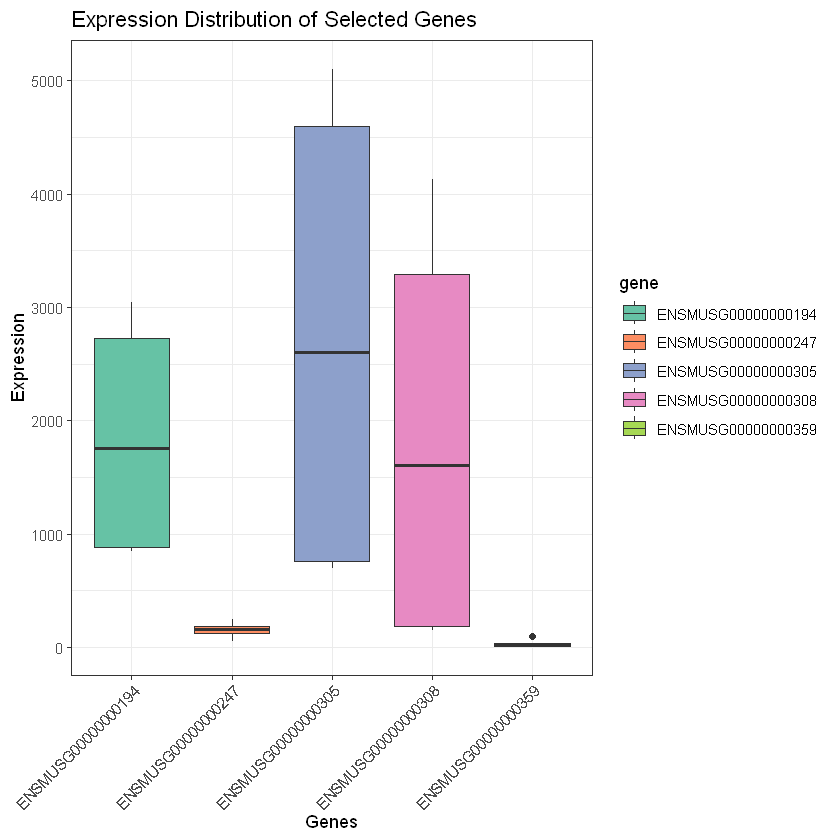

In [18]:
df <- as.data.frame(t(assay(rna)[1:5, ]))
df$sample <- rownames(df)
df_long <- pivot_longer(
  df, -sample, names_to = "gene", values_to = "expression")
# -sample tells to pivot every column in the dataframe EXCEPT the sample column

ggplot(df_long, aes(x = gene, y = expression)) +
  geom_boxplot(aes(fill = gene)) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
  labs(
    title = "Expression Distribution of Selected Genes",
    y = "Expression", x = "Genes") +
  scale_fill_brewer(palette = "Set2")

## Question 1

Make a `boxplot` of samples, before and after normalization.

_Hint:_ Check `assays` of `rna` object. Raw counts should be converted to `log2` to make a comparison.

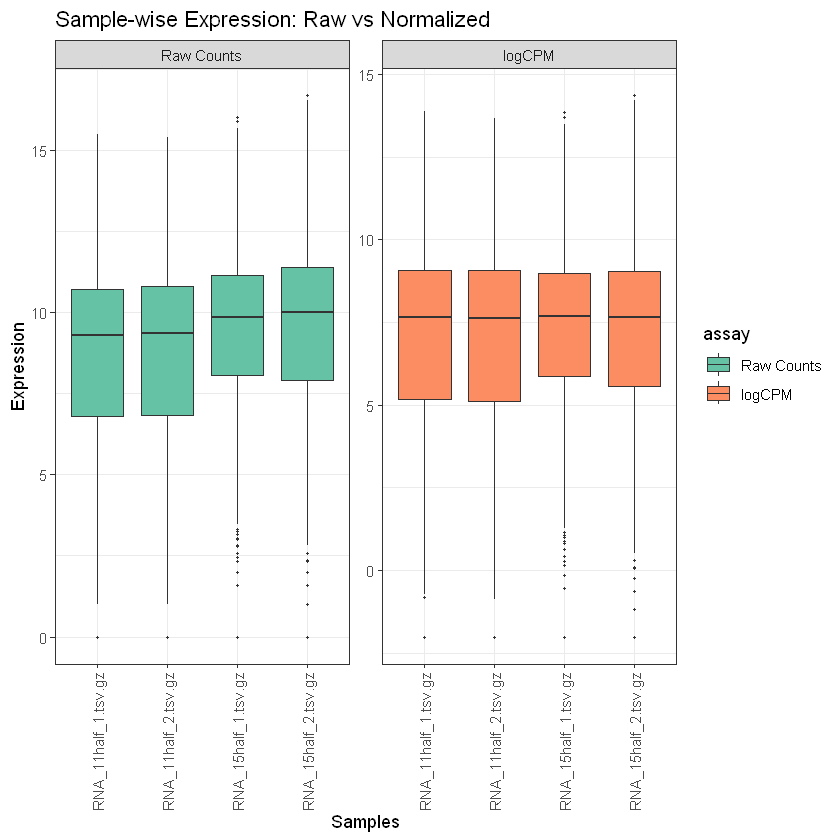

In [19]:
# Extract assays
raw_counts <- assay(rna, "counts")
logcpm <- assay(rna, "logCPM")

# Convert to long data frames for ggplot
df_raw <- as.data.frame(raw_counts)
df_raw$gene <- rownames(df_raw)
df_raw_long <- pivot_longer(
  df_raw, -gene, names_to = "sample", values_to = "expression")
df_raw_long$assay <- "Raw Counts"
df_raw_long$expression <- log2(df_raw_long$expression + 1)

df_log <- as.data.frame(logcpm)
df_log$gene <- rownames(df_log)
df_log_long <- pivot_longer(
  df_log, -gene, names_to = "sample", values_to = "expression")
df_log_long$assay <- "logCPM"

# Combine both
df_combined <- rbind(df_raw_long, df_log_long)

# Set factor for names to make Raw counts to be plotted first
df_combined$assay <- factor(
  df_combined$assay,
  levels = unique(df_combined$assay))

# Plot boxplot across samples
ggplot(df_combined, aes(x = sample, y = expression, fill = assay)) +
  geom_boxplot(outlier.size = 0.5, lwd = 0.3) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1)) +
  facet_wrap(~ assay, scales = "free_y") +
  labs(
    title = "Sample-wise Expression: Raw vs Normalized",
    x = "Samples", y = "Expression") +
  scale_fill_brewer(palette = "Set2")

## Question 2

Make a new `SummarizedExperiment` object by sub-setting `rna`.

Take only first 2 samples and first 10 genes. Check the `assays`, row and column metadata.

In [20]:
rna_subset <- rna[1:10, 1:2]
rna_subset

assays(rna_subset)

class: RangedSummarizedExperiment 
dim: 10 2 
metadata(0):
assays(2): counts logCPM
rownames(10): ENSMUSG00000000194 ENSMUSG00000000247 ... ENSMUSG00000000827 ENSMUSG00000000876
rowData names(18): Row.names gene_id ... PValue qvalue
colnames(2): RNA_11half_1.tsv.gz RNA_11half_2.tsv.gz
colData names(2): sample group

List of length 2
names(2): counts logCPM

In [21]:
assay(rna_subset, "counts")

,RNA_11half_1.tsv.gz,RNA_11half_2.tsv.gz
,<dbl>,<dbl>
ENSMUSG00000000194,848.00,893.35
ENSMUSG00000000247,169.00,246.00
ENSMUSG00000000305,694.00,778.00
ENSMUSG00000000308,148.00,195.00
ENSMUSG00000000359,8.00,13.00
ENSMUSG00000000392,349.00,333.00
ENSMUSG00000000823,1851.87,2077.29
ENSMUSG00000000826,5908.00,7011.00
ENSMUSG00000000827,2788.23,2998.49


In [22]:
colData(rna_subset)

DataFrame with 2 rows and 2 columns
                                 sample    group
                            <character> <factor>
RNA_11half_1.tsv.gz RNA_11half_1.tsv.gz   11half
RNA_11half_2.tsv.gz RNA_11half_2.tsv.gz   11half

In [23]:
rowRanges(rna_subset)

GRanges object with 10 ranges and 18 metadata columns:
                     seqnames              ranges strand |          Row.names     gene_id      SYMBOL               GENENAME
                        <Rle>           <IRanges>  <Rle> |        <character> <character> <character>            <character>
  ENSMUSG00000000194     chr2   31152316-31218775      + | ENSMUSG00000000194      277463      Gpr107 G protein-coupled re..
  ENSMUSG00000000247     chr2   38339281-38369733      + | ENSMUSG00000000247       16870        Lhx2 LIM homeobox protein 2
  ENSMUSG00000000305     chr2 179442431-179899373      + | ENSMUSG00000000305       12561        Cdh4             cadherin 4
  ENSMUSG00000000308     chr2 121357714-121363737      + | ENSMUSG00000000308       12716       Ckmt1 creatine kinase, mit..
  ENSMUSG00000000359     chr2 152626951-152635198      + | ENSMUSG00000000359       19700        Rem1 rad and gem related ..
  ENSMUSG00000000392     chr2   62500943-62574075      - | ENSMUSG0000

In [24]:
length(rowRanges(rna_subset))

[1] 10

## Question 3

Try to run all other commands from the following image on other `SE` objects as well.

<img src="../assets/img/se.svg" width="600">

In [25]:
h3k27ac

colData(h3k27ac)
assays(h3k27ac)

class: RangedSummarizedExperiment 
dim: 24231 4 
metadata(2): final.ext param
assays(2): counts logCPM
rownames: NULL
rowData names(18): annotation geneChr ... PValue qvalue
colnames: NULL
colData names(6): bam.files totals ... group norm.factors

DataFrame with 4 rows and 6 columns
               bam.files    totals       ext      rlen       group norm.factors
             <character> <integer> <integer> <integer> <character>    <numeric>
1 ../data/H3K27ac_11ha..  38907314       100        36      11half     0.916676
2 ../data/H3K27ac_11ha..  38213305       100        36      11half     0.893381
3 ../data/H3K27ac_15ha..  83981374       100        49      15half     1.096524
4 ../data/H3K27ac_15ha..  94077476       100        49      15half     1.113600

List of length 2
names(2): counts logCPM

In [26]:
head(assay(h3k27ac, "logCPM"))

4.157836,-1.072886,1.135676,1.540448
3.659635,2.072572,4.200268,3.435317
3.326437,2.808303,4.145176,3.884800
3.052044,2.072572,4.353945,4.382375
4.226394,3.944796,5.805263,5.680163
2.507844,3.655477,1.135676,2.417469


In [27]:
metadata(h3k27ac)

Le chargement a nécessité le package : csaw



$final.ext
[1] NA

$param
An object of class "readParam"
Slot "pe":
[1] "none"

Slot "max.frag":
[1] 500

Slot "dedup":
[1] FALSE

Slot "minq":
[1] NA

Slot "forward":
[1] NA

Slot "restrict":
character(0)

Slot "discard":
GRanges object with 0 ranges and 0 metadata columns:
   seqnames    ranges strand
      <Rle> <IRanges>  <Rle>
  -------
  seqinfo: no sequences

Slot "processed.discard":
named list()



## Working with `GRanges`

### Extract and Inspect `GRanges` from ATAC-seq

In [28]:
gr <- rowRanges(atac)
gr

GRanges object with 3656 ranges and 18 metadata columns:
         seqnames              ranges strand |             annotation   geneChr geneStart   geneEnd geneLength geneStrand      geneId
            <Rle>           <IRanges>  <Rle> |            <character> <integer> <integer> <integer>  <integer>  <integer> <character>
     [1]     chr1     3670547-3672665      * |       Promoter (<=1kb)         1   3214482   3671498     457017          2      497097
     [2]     chr1     4332510-4332710      * | Intron (ENSMUST00000..         1   4344146   4360314      16169          2       19888
     [3]     chr1     4491755-4492573      * |       Promoter (1-2kb)         1   4492465   4493735       1271          2       20671
     [4]     chr1     4571186-4572423      * |      Distal Intergenic         1   4491390   4497354       5965          2       20671
     [5]     chr1     4785062-4786325      * |       Promoter (<=1kb)         1   4773206   4785710      12505          2       27395
     

In [29]:
seqlevels(gr)

[1] "chr1"  "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8"  "chr9"  "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17"
[18] "chr18" "chr19" "chrX"  "chrY"

### Subset Regions on chr1 with Width > 1000 bp

`width` (along with seqnames, start, end, and strand) is not in the metadata columns (mcols). It is a core spatial property of the GRanges object itself. It calculates width simply as _end - start + 1_. For a gene, this represents the entire genomic locus on the chromosome, spanning from the start of the first exon all the way to the end of the last exon, including all the introns.

In [30]:
subset_gr <- gr[seqnames(gr) == "chr1" & width(gr) > 1000]
length(subset_gr)

[1] 838

Bioconductor has a specialized `subset` method for GRanges that allows us to drop the repetitive `gr` calls, making it look much cleaner:

In [31]:
subset(gr, seqnames == "chr1" & width > 1000)

GRanges object with 838 ranges and 18 metadata columns:
        seqnames              ranges strand |        annotation   geneChr geneStart   geneEnd geneLength geneStrand      geneId
           <Rle>           <IRanges>  <Rle> |       <character> <integer> <integer> <integer>  <integer>  <integer> <character>
    [1]     chr1     3670547-3672665      * |  Promoter (<=1kb)         1   3214482   3671498     457017          2      497097
    [2]     chr1     4571186-4572423      * | Distal Intergenic         1   4491390   4497354       5965          2       20671
    [3]     chr1     4785062-4786325      * |  Promoter (<=1kb)         1   4773206   4785710      12505          2       27395
    [4]     chr1     4807268-4808558      * |  Promoter (<=1kb)         1   4807788   4848410      40623          1       18777
    [5]     chr1     4857303-4858480      * |  Promoter (<=1kb)         1   4857814   4897905      40092          1       21399
    ...      ...                 ...    ... .   

### Plot Width Distribution of Genomic Ranges

`mcols(gr)` (Metadata only) returns only the extra annotations (the "fact sheet"). It returns a DataFrame of things like Gene Name, P-value, or Score. It does not include the actual genomic coordinates (seqnames, start, end, width, strand). `as.data.frame(gr)` (Everything) flattens the entire GRanges object into a standard R dataframe. The resulting table will have seqnames, start, end, width, and strand as its first five columns, and then it will attach all of the mcols right next to them.

We must use `as.data.frame(gr)` here. If we used mcols(gr), the resulting table wouldn't have the **width** column.

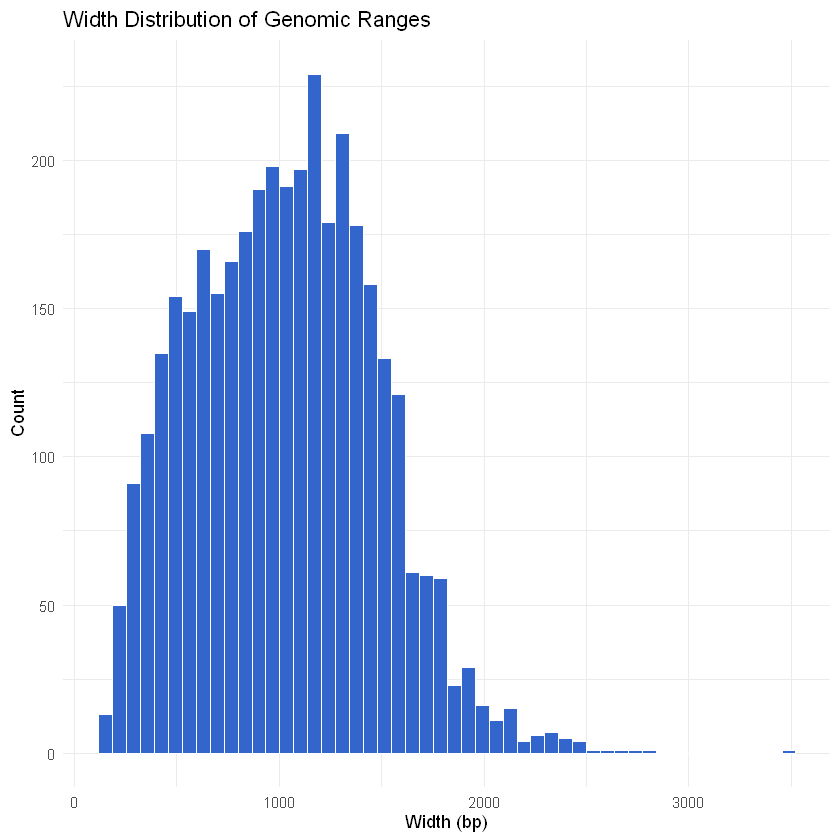

In [32]:
df_gr <- as.data.frame(gr)

ggplot(df_gr, aes(x = width)) +
  geom_histogram(bins = 50, fill = "#3366cc", color = "white") +
  theme_minimal() +
  labs(
    title = "Width Distribution of Genomic Ranges",
    x = "Width (bp)", y = "Count")

The _geneLength_ column in the metadata is usually the effective length of the mature mRNA transcript. It is calculated by summing up only the lengths of the exons (ignoring the introns). This is the number used to normalize counts into TPM (Transcripts Per Million).

## Heatmap of H3K27ac Signal

In [33]:
mat <- assay(h3k27ac)
head(mat)

20,0,5,8
14,4,52,34
11,7,50,47
9,4,58,67
21,16,161,167
6,13,5,16


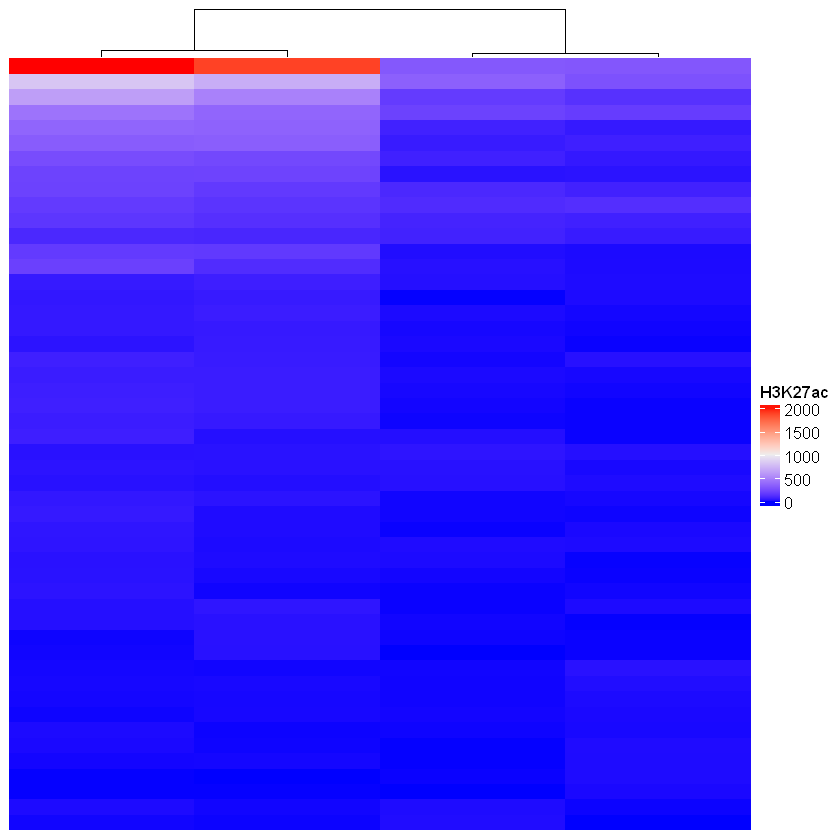

In [34]:
Heatmap(
  mat[1:50,],
  name = "H3K27ac",
  show_row_names = FALSE,
  show_column_names = TRUE,
  cluster_rows = TRUE,
  show_row_dend = FALSE,  # hide row dendrogram
  cluster_columns = TRUE)

## Question 4

Try to run all other commands from the following image on other `GRanges` from `SE` objects as well.

<img src="../assets/img/gr.png" width="600">

In [35]:
gr <- rowRanges(h3k4me1)
head(gr)

GRanges object with 6 ranges and 18 metadata columns:
      seqnames          ranges strand |             annotation   geneChr geneStart   geneEnd geneLength geneStrand      geneId
         <Rle>       <IRanges>  <Rle> |            <character> <integer> <integer> <integer>  <integer>  <integer> <character>
  [1]     chr1 3120410-3120664      * |      Distal Intergenic         1   3214482   3671498     457017          2      497097
  [2]     chr1 3254884-3255166      * | Intron (ENSMUST00000..         1   3214482   3671498     457017          2      497097
  [3]     chr1 3366339-3366557      * | Exon (ENSMUST0000019..         1   3214482   3671498     457017          2      497097
  [4]     chr1 3368377-3368571      * | Exon (ENSMUST0000019..         1   3214482   3671498     457017          2      497097
  [5]     chr1 3398970-3399433      * | Intron (ENSMUST00000..         1   3214482   3671498     457017          2      497097
  [6]     chr1 3399520-3400407      * | Intron (ENSMUST00

In [36]:
length(gr)

[1] 41330

In the context of ChIP-seq (or ATAC-seq), the core geometry of your GRanges object represents the peaks (the specific, relatively short regions where a protein bound or chromatin is open, often just 200--1000 bp).

If you have annotated those peaks to nearby genes, the genes themselves have their own "start" and "end" coordinates, which can span tens or hundreds of thousands of base pairs.

In [37]:
head(width(gr))  # length between IRanges bounds, not between start and end of gene!

[1] 255 283 219 195 464 888

In [38]:
head(gr$geneLength)  # head(mcols(gr)$geneLength)

[1] 457017 457017 457017 457017 457017 457017

::: {.callout-important}
Understanding how different omics layers are represented in `SE` and `GRanges` objects is essential for multi-omics integration, visualization, and downstream analysis.
:::